<a href="https://colab.research.google.com/github/huiningjiao02-ship-it/Conformer-EEG-BCI-Decoding-Pipeline/blob/main/Conformer_EEG_BCI_Decoding_Pipeline_Repeated_Subject_Dependent_Protocol_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 — Setup

!pip -q install mne einops scikit-learn tqdm

import os
import time
import random
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne.datasets import eegbci

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


@dataclass
class CFG:
    project_name: str = "Conformer-EEG-BCI-Within-Subject-Repeated"
    seed: int = 42

    data_root: str = "/content/eeg_data"
    results_dir: str = "/content/eeg_bci_within_subject_repeated_results"

    subjects: Tuple[int, ...] = tuple(range(1, 6))
    runs: Tuple[int, ...] = (4, 6, 8, 10, 12, 14)

    repeat_seeds: Tuple[int, ...] = (42, 123, 2026)

    sfreq: int = 250
    l_freq: float = 4.0
    h_freq: float = 38.0
    tmin: float = 0.0
    tmax: float = 4.0

    batch_size: int = 16
    epochs: int = 250
    lr: float = 2e-4
    weight_decay: float = 5e-5
    patience: int = 40
    dropout: float = 0.4

    n_classes: int = 4
    emb_size: int = 40
    depth: int = 6
    n_heads: int = 10

    use_augmentation: bool = True
    aug_segments: int = 8
    aug_multiplier: float = 3.0


cfg = CFG()

os.makedirs(cfg.data_root, exist_ok=True)
os.makedirs(cfg.results_dir, exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LABEL_NAMES = {
    0: "left_fist",
    1: "right_fist",
    2: "both_fists",
    3: "both_feet"
}

print("Project:", cfg.project_name)
print("Device:", device)
print("Subjects:", cfg.subjects)
print("Runs:", cfg.runs)
print("Evaluation:", "repeated within-subject")
print("Repeat seeds:", cfg.repeat_seeds)
print("Epochs:", cfg.epochs)
print("Patience:", cfg.patience)
print("Dropout:", cfg.dropout)
print("Transformer depth:", cfg.depth)
print("Attention heads:", cfg.n_heads)
print("Augmentation multiplier:", cfg.aug_multiplier)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 41.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
Project: Conformer-EEG-BCI-Within-Subject-Repeated
Device: cuda
Subjects: (1, 2, 3, 4, 5)
Runs: (4, 6, 8, 10, 12, 14)
Evaluation: repeated within-subject
Repeat seeds: (42, 123, 2026)
Epochs: 250
Patience: 40
Dropout: 0.4
Transformer depth: 6
Attention heads: 10
Augmentation multiplier: 3.0


In [ ]:
# Cell 2 — Data loading and within-subject split

LEFT_RIGHT_RUNS = {3, 4, 7, 8, 11, 12}
FISTS_FEET_RUNS = {5, 6, 9, 10, 13, 14}


def label_from_run(run, annotation):
    if annotation == "T0":
        return None

    if run in LEFT_RIGHT_RUNS:
        if annotation == "T1":
            return 0
        if annotation == "T2":
            return 1

    if run in FISTS_FEET_RUNS:
        if annotation == "T1":
            return 2
        if annotation == "T2":
            return 3

    return None


def load_subject(subject, cfg=cfg):
    file_paths = eegbci.load_data(
        subject,
        list(cfg.runs),
        path=cfg.data_root,
        verbose=False
    )

    all_X = []
    all_y = []
    ch_names = None

    for file_path, run in zip(file_paths, cfg.runs):
        raw = mne.io.read_raw_edf(
            file_path,
            preload=True,
            verbose=False
        )

        eegbci.standardize(raw)
        raw.pick_types(eeg=True)

        montage = mne.channels.make_standard_montage("standard_1005")

        raw.set_montage(
            montage,
            on_missing="ignore",
            verbose=False
        )

        raw.filter(
            cfg.l_freq,
            cfg.h_freq,
            fir_design="firwin",
            verbose=False
        )

        raw.resample(
            cfg.sfreq,
            npad="auto",
            verbose=False
        )

        events, event_id = mne.events_from_annotations(
            raw,
            verbose=False
        )

        selected_event_id = {}

        if "T1" in event_id:
            selected_event_id["T1"] = event_id["T1"]

        if "T2" in event_id:
            selected_event_id["T2"] = event_id["T2"]

        if len(selected_event_id) == 0:
            continue

        epochs = mne.Epochs(
            raw,
            events,
            event_id=selected_event_id,
            tmin=cfg.tmin,
            tmax=cfg.tmax,
            baseline=None,
            preload=True,
            reject_by_annotation=True,
            verbose=False
        )

        X_run = epochs.get_data()
        inv_event_id = {v: k for k, v in event_id.items()}

        y_run = []
        keep_idx = []

        for i, event in enumerate(epochs.events):
            annotation = inv_event_id[event[-1]]
            label = label_from_run(run, annotation)

            if label is not None:
                y_run.append(label)
                keep_idx.append(i)

        if len(keep_idx) == 0:
            continue

        X_run = X_run[keep_idx]
        y_run = np.array(y_run, dtype=np.int64)

        all_X.append(X_run)
        all_y.append(y_run)

        ch_names = epochs.ch_names

    if len(all_X) == 0:
        raise RuntimeError(f"No valid trials found for subject {subject}.")

    X = np.concatenate(all_X, axis=0).astype(np.float32)
    y = np.concatenate(all_y, axis=0).astype(np.int64)

    return X, y, ch_names


def fit_standardizer(X_train):
    mean = X_train.mean(
        axis=(0, 2),
        keepdims=True
    )

    std = X_train.std(
        axis=(0, 2),
        keepdims=True
    ) + 1e-6

    return mean, std


def apply_standardizer(X, mean, std):
    return (X - mean) / std


def prepare_within_subject_split(X, y, split_seed, cfg=cfg):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=split_seed,
        stratify=y
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=split_seed,
        stratify=y_temp
    )

    mean, std = fit_standardizer(X_train)

    X_train = apply_standardizer(X_train, mean, std)
    X_val = apply_standardizer(X_val, mean, std)
    X_test = apply_standardizer(X_test, mean, std)

    return X_train, y_train, X_val, y_val, X_test, y_test


def load_subject_bank(subjects, cfg=cfg):
    bank = {}

    for subject in subjects:
        print(f"Loading subject {subject}...")

        X, y, ch_names = load_subject(subject, cfg)

        bank[subject] = {
            "X": X,
            "y": y,
            "ch_names": ch_names
        }

        dist = {
            LABEL_NAMES[i]: int(np.sum(y == i))
            for i in range(cfg.n_classes)
        }

        print(f"Subject {subject}: X={X.shape}, class distribution={dist}")

    return bank


subject_bank = load_subject_bank(
    cfg.subjects,
    cfg
)

print("Number of subjects loaded:", len(subject_bank))

Loading subject 1...


Do you want to set the path:
    /content/eeg_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Subject 1: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 21, 'both_feet': 24}
Loading subject 2...


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Subject 2: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 24, 'both_feet': 21}
Loading subject 3...


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 3: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 21, 'both_feet': 24}
Loading subject 4...


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Subject 4: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 22, 'both_feet': 23}
Loading subject 5...


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 5: X=(90, 64, 1001), class distribution={'left_fist': 21, 'right_fist': 24, 'both_fists': 23, 'both_feet': 22}
Number of subjects loaded: 5


In [ ]:
# Cell 3 — Dataset, augmentation, dataloaders, and EEG-Conformer model

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        ).unsqueeze(1)

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def segmentation_reconstruction(X, y, segments=8, multiplier=1.0):
    X_aug = []
    y_aug = []

    n_times = X.shape[-1]

    split_points = np.linspace(
        0,
        n_times,
        segments + 1
    ).astype(int)

    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        n_new = int(len(cls_idx) * multiplier)

        if len(cls_idx) < 2:
            continue

        for _ in range(n_new):
            new_trial = np.zeros_like(X[0])

            for seg in range(segments):
                start = split_points[seg]
                end = split_points[seg + 1]

                source_idx = np.random.choice(cls_idx)
                new_trial[:, start:end] = X[source_idx, :, start:end]

            X_aug.append(new_trial)
            y_aug.append(cls)

    if len(X_aug) == 0:
        return X, y

    X_aug = np.stack(X_aug).astype(np.float32)
    y_aug = np.array(y_aug, dtype=np.int64)

    X_new = np.concatenate(
        [X, X_aug],
        axis=0
    )

    y_new = np.concatenate(
        [y, y_aug],
        axis=0
    )

    return X_new, y_new


def build_loaders(X_train, y_train, X_val, y_val, X_test, y_test, cfg=cfg):
    if cfg.use_augmentation:
        X_train, y_train = segmentation_reconstruction(
            X_train,
            y_train,
            segments=cfg.aug_segments,
            multiplier=cfg.aug_multiplier
        )

    train_loader = DataLoader(
        EEGDataset(X_train, y_train),
        batch_size=cfg.batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        EEGDataset(X_val, y_val),
        batch_size=cfg.batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        EEGDataset(X_test, y_test),
        batch_size=cfg.batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader


class EEGConformer(nn.Module):
    def __init__(self, n_channels, cfg=cfg):
        super().__init__()

        self.patch_embedding = nn.Sequential(
            nn.Conv2d(
                1,
                cfg.emb_size,
                kernel_size=(1, 25),
                padding=(0, 12),
                bias=False
            ),
            nn.BatchNorm2d(cfg.emb_size),

            nn.Conv2d(
                cfg.emb_size,
                cfg.emb_size,
                kernel_size=(n_channels, 1),
                bias=False
            ),
            nn.BatchNorm2d(cfg.emb_size),
            nn.ELU(),

            nn.AvgPool2d(
                kernel_size=(1, 75),
                stride=(1, 15)
            ),
            nn.Dropout(cfg.dropout)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.emb_size,
            nhead=cfg.n_heads,
            dim_feedforward=cfg.emb_size * 4,
            dropout=cfg.dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=cfg.depth
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(cfg.emb_size),
            nn.Linear(cfg.emb_size, cfg.n_classes)
        )

    def forward(self, x):
        x = self.patch_embedding(x)
        x = x.squeeze(2).permute(0, 2, 1)
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.classifier(x)

        return x

In [ ]:
# Cell 4 — Repeated within-subject training and evaluation

def evaluate_model(model, loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss()

    all_y = []
    all_pred = []
    total_loss = 0.0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            logits = model(X)
            loss = criterion(logits, y)

            total_loss += loss.item() * len(y)

            pred = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_pred.extend(pred.cpu().numpy())

    all_y = np.array(all_y)
    all_pred = np.array(all_pred)

    metrics = {
        "loss": total_loss / len(all_y),
        "accuracy": accuracy_score(all_y, all_pred),
        "balanced_accuracy": balanced_accuracy_score(all_y, all_pred),
        "macro_f1": f1_score(
            all_y,
            all_pred,
            average="macro",
            zero_division=0
        ),
        "confusion_matrix": confusion_matrix(
            all_y,
            all_pred,
            labels=list(range(cfg.n_classes))
        )
    }

    return metrics, all_y, all_pred


def train_one_subject_seed(model, train_loader, val_loader, cfg=cfg, device=device):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay
    )

    best_score = -1.0
    best_state = None
    wait = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": []
    }

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        total_loss = 0.0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(X)
            loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y)

        train_loss = total_loss / len(train_loader.dataset)

        val_metrics, _, _ = evaluate_model(
            model,
            val_loader,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val Macro-F1: {val_metrics['macro_f1']:.4f}"
        )

        score = val_metrics["macro_f1"]

        if score > best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if wait >= cfg.patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)

    return model, history


def run_repeated_within_subject_experiment(subject_bank, cfg=cfg):
    all_results = []
    histories = {}
    predictions = {}

    print("Evaluation protocol: repeated within-subject")
    print("Total subjects:", len(subject_bank))
    print("Repeat seeds:", cfg.repeat_seeds)
    print("Total training runs:", len(subject_bank) * len(cfg.repeat_seeds))

    for subject in sorted(subject_bank.keys()):
        X = subject_bank[subject]["X"]
        y = subject_bank[subject]["y"]

        for split_seed in cfg.repeat_seeds:
            print("\n" + "=" * 80)
            print(f"Subject {subject} | Split seed {split_seed}")
            print("=" * 80)

            set_seed(split_seed)

            start_time = time.time()

            X_train, y_train, X_val, y_val, X_test, y_test = prepare_within_subject_split(
                X,
                y,
                split_seed=split_seed,
                cfg=cfg
            )

            print("X_train:", X_train.shape)
            print("X_val:  ", X_val.shape)
            print("X_test: ", X_test.shape)

            train_loader, val_loader, test_loader = build_loaders(
                X_train,
                y_train,
                X_val,
                y_val,
                X_test,
                y_test,
                cfg
            )

            n_channels = X_train.shape[1]

            model = EEGConformer(
                n_channels=n_channels,
                cfg=cfg
            )

            model, history = train_one_subject_seed(
                model,
                train_loader,
                val_loader,
                cfg,
                device
            )

            test_metrics, y_true, y_pred = evaluate_model(
                model,
                test_loader,
                device
            )

            used_time = time.time() - start_time

            result = {
                "subject": subject,
                "split_seed": split_seed,
                "protocol": "repeated_within_subject",
                "test_accuracy": test_metrics["accuracy"],
                "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                "test_macro_f1": test_metrics["macro_f1"],
                "test_loss": test_metrics["loss"],
                "used_time_seconds": used_time,
                "confusion_matrix": test_metrics["confusion_matrix"]
            }

            all_results.append(result)

            key = f"subject_{subject}_seed_{split_seed}"
            histories[key] = history
            predictions[key] = {
                "y_true": y_true,
                "y_pred": y_pred
            }

            print(
                f"Finished subject {subject} | "
                f"Seed {split_seed} | "
                f"Acc: {result['test_accuracy']:.4f} | "
                f"Balanced Acc: {result['test_balanced_accuracy']:.4f} | "
                f"Macro-F1: {result['test_macro_f1']:.4f} | "
                f"Time: {used_time / 60:.2f} min"
            )

            temp_df = pd.DataFrame(all_results)

            temp_df.drop(
                columns=["confusion_matrix"],
                errors="ignore"
            ).to_csv(
                os.path.join(cfg.results_dir, "repeated_within_subject_partial_results.csv"),
                index=False
            )

    repeated_df = pd.DataFrame(all_results)

    repeated_df.drop(
        columns=["confusion_matrix"],
        errors="ignore"
    ).to_csv(
        os.path.join(cfg.results_dir, "repeated_within_subject_all_results.csv"),
        index=False
    )

    return repeated_df, histories, predictions


repeated_df, histories, predictions = run_repeated_within_subject_experiment(
    subject_bank,
    cfg=cfg
)

display(
    repeated_df.drop(
        columns=["confusion_matrix"],
        errors="ignore"
    )
)

Evaluation protocol: repeated within-subject
Total subjects: 5
Repeat seeds: (42, 123, 2026)
Total training runs: 15

Subject 1 | Split seed 42
X_train: (63, 64, 1001)
X_val:   (13, 64, 1001)
X_test:  (14, 64, 1001)
Epoch 001 | Train Loss: 1.3665 | Val Loss: 1.4159 | Val Acc: 0.2308 | Val Macro-F1: 0.1883
Epoch 002 | Train Loss: 1.1575 | Val Loss: 1.3029 | Val Acc: 0.3077 | Val Macro-F1: 0.3179
Epoch 003 | Train Loss: 0.9340 | Val Loss: 1.1730 | Val Acc: 0.4615 | Val Macro-F1: 0.3750
Epoch 004 | Train Loss: 0.7633 | Val Loss: 1.0486 | Val Acc: 0.5385 | Val Macro-F1: 0.4583
Epoch 005 | Train Loss: 0.5624 | Val Loss: 1.3458 | Val Acc: 0.3846 | Val Macro-F1: 0.2611
Epoch 006 | Train Loss: 0.4690 | Val Loss: 1.5037 | Val Acc: 0.3077 | Val Macro-F1: 0.2338
Epoch 007 | Train Loss: 0.4121 | Val Loss: 1.1656 | Val Acc: 0.4615 | Val Macro-F1: 0.4345
Epoch 008 | Train Loss: 0.4242 | Val Loss: 1.2592 | Val Acc: 0.3077 | Val Macro-F1: 0.2429
Epoch 009 | Train Loss: 0.3393 | Val Loss: 1.1286 | Val 

,subject,split_seed,protocol,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss,used_time_seconds
0,1,42,repeated_within_subject,0.785714,0.750000,0.666667,0.903940,66.832469
1,1,123,repeated_within_subject,0.857143,0.833333,0.811508,0.961588,84.789474
2,1,2026,repeated_within_subject,0.500000,0.541667,0.486111,1.257541,49.575845
3,2,42,repeated_within_subject,0.571429,0.541667,0.520513,0.794552,98.660002
4,2,123,repeated_within_subject,0.642857,0.625000,0.616342,0.941374,43.579803
5,2,2026,repeated_within_subject,0.928571,0.937500,0.936508,0.235680,113.495638
6,3,42,repeated_within_subject,0.642857,0.666667,0.639881,0.844120,60.251810
7,3,123,repeated_within_subject,0.714286,0.750000,0.695238,0.736169,66.433400
8,3,2026,repeated_within_subject,0.357143,0.354167,0.311111,1.238706,41.360365
9,4,42,repeated_within_subject,0.714286,0.708333,0.717857,0.718795,70.952322


Number of total runs:
15

Overall mean results:
test_accuracy              0.576190
test_balanced_accuracy     0.573611
test_macro_f1              0.546906
test_loss                  1.317021
used_time_seconds         65.988738
dtype: float64

Overall standard deviation:
test_accuracy              0.199245
test_balanced_accuracy     0.200271
test_macro_f1              0.200719
test_loss                  0.778456
used_time_seconds         21.049103
dtype: float64

Per-subject mean and standard deviation:


test_accuracy           test_balanced_accuracy            \
                 mean       std                   mean       std   
subject                                                            
1            0.714286  0.188982               0.708333  0.150231   
2            0.714286  0.188982               0.701389  0.208680   
3            0.571429  0.188982               0.590278  0.208680   
4            0.500000  0.188982               0.479167  0.200909   
5            0.380952  0.109109               0.388889  0.118463   

        test_macro_f1           test_loss           used_time_seconds  \
                 mean       std      mean       std              mean   
subject                                                                 
1            0.654762  0.163025  1.041023  0.189712         67.065929   
2            0.691121  0.217846  0.657202  0.372357         85.245148   
3            0.548743  0.207649  0.939665  0.264542         56.015191   
4            0.486003  0.204126  1.613377  1.004089         64.872693   
5            0.353902  0.114490  2.333840  0.570631         56.744729   

                    
               std  
subject             
1        17.607975  
2        36.837817  
3        13.062388  
4        19.427759  
5         7.008274


Saved all results to: /content/eeg_bci_within_subject_repeated_results/repeated_within_subject_all_results.csv
Saved subject summary to: /content/eeg_bci_within_subject_repeated_results/repeated_within_subject_subject_summary.csv


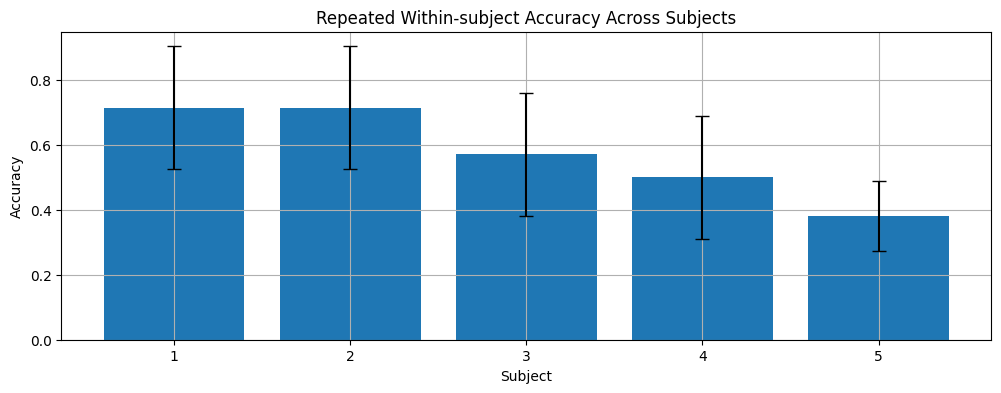

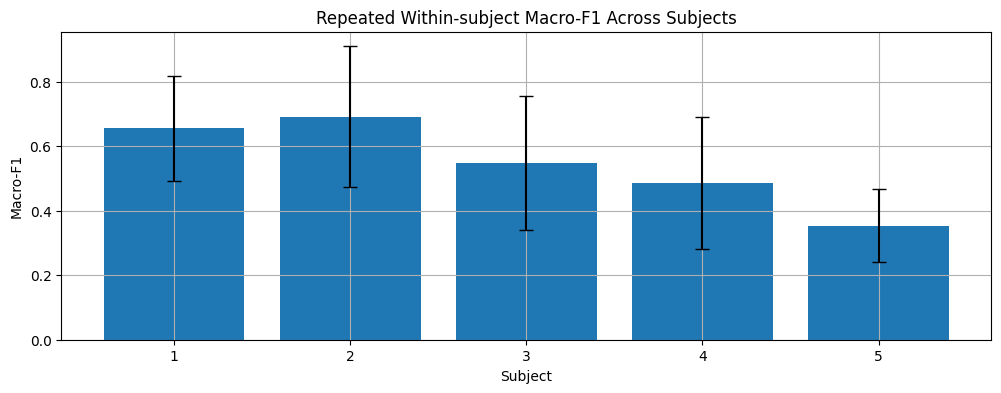


Best single run:


,subject,split_seed,protocol,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss,used_time_seconds
5,2,2026,repeated_within_subject,0.928571,0.9375,0.936508,0.23568,113.495638


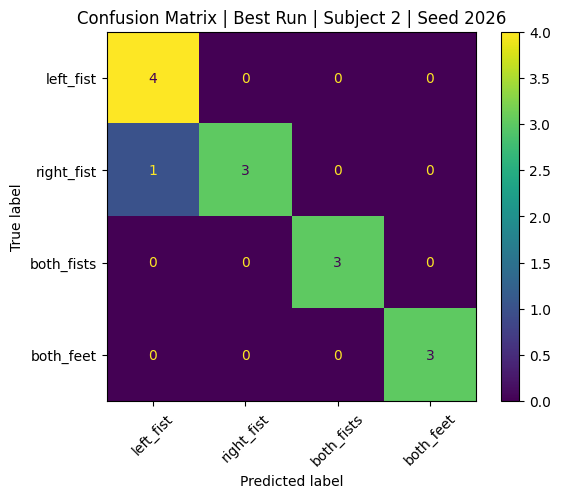

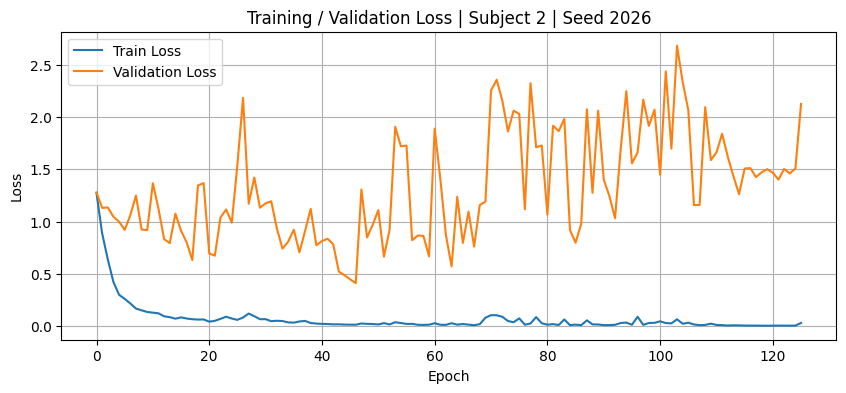


Best subjects by mean accuracy:


,subject,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,std_macro_f1,mean_test_loss,std_test_loss,mean_time_seconds,std_time_seconds
0,1,0.714286,0.188982,0.708333,0.150231,0.654762,0.163025,1.041023,0.189712,67.065929,17.607975
1,2,0.714286,0.188982,0.701389,0.208680,0.691121,0.217846,0.657202,0.372357,85.245148,36.837817
2,3,0.571429,0.188982,0.590278,0.208680,0.548743,0.207649,0.939665,0.264542,56.015191,13.062388
3,4,0.500000,0.188982,0.479167,0.200909,0.486003,0.204126,1.613377,1.004089,64.872693,19.427759
4,5,0.380952,0.109109,0.388889,0.118463,0.353902,0.114490,2.333840,0.570631,56.744729,7.008274



All repeated runs sorted by accuracy:


,subject,split_seed,protocol,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss,used_time_seconds
5,2,2026,repeated_within_subject,0.928571,0.937500,0.936508,0.235680,113.495638
1,1,123,repeated_within_subject,0.857143,0.833333,0.811508,0.961588,84.789474
0,1,42,repeated_within_subject,0.785714,0.750000,0.666667,0.903940,66.832469
9,4,42,repeated_within_subject,0.714286,0.708333,0.717857,0.718795,70.952322
7,3,123,repeated_within_subject,0.714286,0.750000,0.695238,0.736169,66.433400
6,3,42,repeated_within_subject,0.642857,0.666667,0.639881,0.844120,60.251810
4,2,123,repeated_within_subject,0.642857,0.625000,0.616342,0.941374,43.579803
3,2,42,repeated_within_subject,0.571429,0.541667,0.520513,0.794552,98.660002
2,1,2026,repeated_within_subject,0.500000,0.541667,0.486111,1.257541,49.575845
12,5,42,repeated_within_subject,0.500000,0.520833,0.483333,1.715654,49.110812


In [ ]:
# Cell 5 — Results and visualization

repeated_summary = repeated_df.drop(
    columns=["confusion_matrix"],
    errors="ignore"
)

print("Number of total runs:")
print(len(repeated_summary))

print("\nOverall mean results:")

overall_mean = repeated_summary[
    [
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
        "test_loss",
        "used_time_seconds"
    ]
].mean()

print(overall_mean)

print("\nOverall standard deviation:")

overall_std = repeated_summary[
    [
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
        "test_loss",
        "used_time_seconds"
    ]
].std()

print(overall_std)


subject_summary = repeated_summary.groupby("subject")[
    [
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
        "test_loss",
        "used_time_seconds"
    ]
].agg(["mean", "std"])

print("\nPer-subject mean and standard deviation:")
display(subject_summary)


flat_subject_summary = repeated_summary.groupby("subject").agg(
    mean_accuracy=("test_accuracy", "mean"),
    std_accuracy=("test_accuracy", "std"),
    mean_balanced_accuracy=("test_balanced_accuracy", "mean"),
    std_balanced_accuracy=("test_balanced_accuracy", "std"),
    mean_macro_f1=("test_macro_f1", "mean"),
    std_macro_f1=("test_macro_f1", "std"),
    mean_test_loss=("test_loss", "mean"),
    std_test_loss=("test_loss", "std"),
    mean_time_seconds=("used_time_seconds", "mean"),
    std_time_seconds=("used_time_seconds", "std")
).reset_index()

all_results_path = os.path.join(
    cfg.results_dir,
    "repeated_within_subject_all_results.csv"
)

subject_summary_path = os.path.join(
    cfg.results_dir,
    "repeated_within_subject_subject_summary.csv"
)

repeated_summary.to_csv(
    all_results_path,
    index=False
)

flat_subject_summary.to_csv(
    subject_summary_path,
    index=False
)

print("\nSaved all results to:", all_results_path)
print("Saved subject summary to:", subject_summary_path)


plt.figure(figsize=(12, 4))
plt.bar(
    flat_subject_summary["subject"],
    flat_subject_summary["mean_accuracy"],
    yerr=flat_subject_summary["std_accuracy"],
    capsize=5
)
plt.xlabel("Subject")
plt.ylabel("Accuracy")
plt.title("Repeated Within-subject Accuracy Across Subjects")
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 4))
plt.bar(
    flat_subject_summary["subject"],
    flat_subject_summary["mean_macro_f1"],
    yerr=flat_subject_summary["std_macro_f1"],
    capsize=5
)
plt.xlabel("Subject")
plt.ylabel("Macro-F1")
plt.title("Repeated Within-subject Macro-F1 Across Subjects")
plt.grid(True)
plt.show()


best_row = repeated_summary.sort_values(
    "test_accuracy",
    ascending=False
).iloc[0]

best_subject = int(best_row["subject"])
best_seed = int(best_row["split_seed"])

print("\nBest single run:")
display(best_row.to_frame().T)

best_cm = repeated_df[
    (repeated_df["subject"] == best_subject) &
    (repeated_df["split_seed"] == best_seed)
]["confusion_matrix"].iloc[0]

disp = ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=[
        LABEL_NAMES[i]
        for i in range(cfg.n_classes)
    ]
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title(f"Confusion Matrix | Best Run | Subject {best_subject} | Seed {best_seed}")
plt.show()


best_key = f"subject_{best_subject}_seed_{best_seed}"
history = histories[best_key]

plt.figure(figsize=(10, 4))
plt.plot(
    history["train_loss"],
    label="Train Loss"
)
plt.plot(
    history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training / Validation Loss | Subject {best_subject} | Seed {best_seed}")
plt.legend()
plt.grid(True)
plt.show()


print("\nBest subjects by mean accuracy:")

display(
    flat_subject_summary.sort_values(
        "mean_accuracy",
        ascending=False
    )
)

print("\nAll repeated runs sorted by accuracy:")

display(
    repeated_summary.sort_values(
        "test_accuracy",
        ascending=False
    )
)